In [3]:
import lfox
import lfox.lattice as lat
import lfox.evolution.hmc as lhmc
import jax
import jax.numpy as jnp
import numpy as np

# Imports below require "dev" environment
import matplotlib.pyplot as plt
import lsqfit
import gvar as gv
import tqdm

In [4]:
d = 4
L = 8

In [5]:
import os

jax.config.update('jax_threefry_partitionable', True)

os.environ['XLA_FLAGS'] = '--xla_force_host_platform_device_count=16'
jax.devices()

I0000 00:00:1695840696.305520       1 tfrt_cpu_pjrt_client.cc:349] TfrtCpuClient created.


[CpuDevice(id=0),
 CpuDevice(id=1),
 CpuDevice(id=2),
 CpuDevice(id=3),
 CpuDevice(id=4),
 CpuDevice(id=5),
 CpuDevice(id=6),
 CpuDevice(id=7),
 CpuDevice(id=8),
 CpuDevice(id=9),
 CpuDevice(id=10),
 CpuDevice(id=11),
 CpuDevice(id=12),
 CpuDevice(id=13),
 CpuDevice(id=14),
 CpuDevice(id=15)]

In [6]:
MyLat = lat.SquareLattice(dims=((L,)*d))
MyLat

In [7]:
phi_field = lat.LatticeField(MyLat)
phi_field.field = np.ones_like(phi_field.field)  # Cold start

In [8]:
from jax.sharding import PositionalSharding
from jax.experimental import mesh_utils

sharding = PositionalSharding(mesh_utils.create_device_mesh((2,2,2,2)))
x = jax.random.normal(jax.random.PRNGKey(1), (16, 16, 16, 16))
y = jax.device_put(x, sharding)

In [9]:
@jax.jit
def scalar_action(phi, kappa, lamb):
    S = 0.0
    F = phi.field
    for ax in range(d):
        S -= 2 * kappa * jnp.sum(F * phi.nn_field(ax))
    phi2 = F**2
    S += jnp.sum(phi2)
    S += lamb * jnp.sum( (phi2-1)**2 )

    return S

In [10]:
%time scalar_action(phi_field, 0.16, 1.1689)

CPU times: user 50.1 ms, sys: 11.8 ms, total: 61.9 ms
Wall time: 51.4 ms


Array(-1146.8799, dtype=float32)

In [11]:
T = 14.4  # 9 ms
flops = (L**d) * (3 + 2*d) + (L**d - 1) * 3
print(flops, flops/T/1e9)  # GFlops

57341 3.982013888888889e-06


In [12]:
phi_shard = jax.device_put(phi_field, sharding)

In [13]:
%%time
scalar_action(phi_shard, 0.16, 1.1689).block_until_ready()

CPU times: user 115 ms, sys: 21.6 ms, total: 136 ms
Wall time: 91.5 ms


Array(-1146.8799, dtype=float32)

In [14]:
T = 4  # 9 ms
flops = (L**d) * (3 + 2*d) + (L**d - 1) * 3
print(flops, flops/T/1e9)  # GFlops

57341 1.433525e-05


In [15]:
class ScalarAction(lhmc.Action):
    @staticmethod
    def _Sjax(phi, kappa, lamb):
        return scalar_action(phi, kappa, lamb)

    def _compute_forces(self):
        self.grads = {
            'phi': jax.jit(jax.grad(scalar_action)),
        }

        def force_func(fields):
            return {'phi': self.grads['phi'](fields['phi'], self.params['kappa'], self.params['lamb']) }

        self.forces = force_func


In [16]:
@jax.jit
def mag(phi):
    return jnp.sum(phi.field)

def mag_obs(fields, params):
    m = mag(fields['phi'])
    m2 = m**2
    m4 = m**4

    return jnp.array([m, m2, m4])

In [17]:
%%time
all_k = [0.15, 0.16, 0.17, 0.175, 0.18, 0.185, 0.19, 0.195, 0.2, 0.21, 0.22]
#all_k = [0.15, 0.16]

all_mags = {}
for ik, k in enumerate(all_k):

    HMC = lhmc.HMCEvolver(
        action=ScalarAction({'phi': phi_field}, params={'kappa': k, 'lamb': 1.1689}),
        seed=1586+ik*5791,
        integrator=lhmc.LeapfrogIntegrator(eps=0.01, Nstep=100),
        observables={'mag': [mag_obs, 10]}
    )

    for _ in range(100):
        HMC.evolve(warmup=True)
    for _ in range(300):
        HMC.evolve()

    all_mags[k] = HMC.obs_chain['mag']


CPU times: user 52.4 s, sys: 13.1 s, total: 1min 5s
Wall time: 50.1 s


In [18]:
print(np.mean(((np.array(all_mags[0.15])/(L**d)))[:,0]))
print(np.mean(((np.array(all_mags[0.16])/(L**d)))[:,0]))
print(np.mean(((np.array(all_mags[0.18])/(L**d)))[:,0]))
print(np.mean(((np.array(all_mags[0.20])/(L**d)))[:,0]))
print(np.mean(((np.array(all_mags[0.22])/(L**d)))[:,0]))

0.67683554
0.7700866
0.8853056
0.9631758
1.0222194


In [19]:
%%time

# Test timing on the HMC tutorial exercise 2.11
Lat6 = lat.SquareLattice(dims=((6,)*d))
phi6 = lat.LatticeField(Lat6)
phi6.field = np.ones_like(phi6.field)

S = ScalarAction({'phi': phi6}, params={'kappa': 0.185825, 'lamb': 1.1689})

HMC6 = lhmc.HMCEvolver(
    action=S,
    seed=195615,
    integrator=lhmc.LeapfrogIntegrator(eps=0.05, Nstep=20),
    observables={'mag': [mag_obs, 10]}
)

for _ in range(100):
    HMC6.evolve(warmup=True)

for _ in range(4900):
    HMC6.evolve()



CPU times: user 2.68 s, sys: 284 ms, total: 2.96 s
Wall time: 2.63 s


In [20]:
np.mean(np.array(HMC6.obs_chain['mag'])[:,0]/(6**4))

0.9117655

In [26]:
np.array(HMC6.obs_chain['mag']).shape

(500, 3)

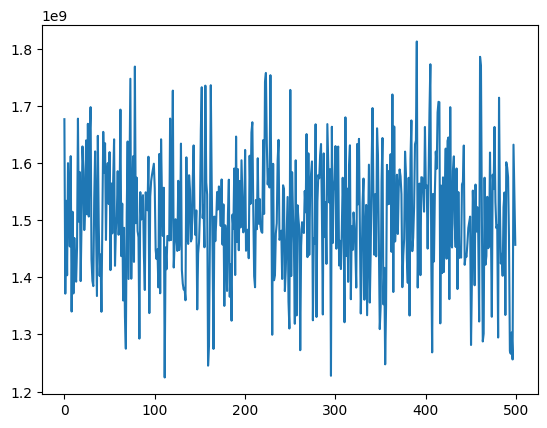

In [28]:
plt.plot((np.array(HMC6.obs_chain['mag'])[:,2])/6**4)